In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
air = pd.read_csv('Statewise Air Quality.csv')

In [4]:
air.head()

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3
0,Ahmedabad,1/1/2015,NaN,NaN,17.15,NaN,0.92,27.64,133.36
1,Ahmedabad,1/2/2015,NaN,NaN,16.46,NaN,0.97,24.55,34.06
2,Ahmedabad,1/3/2015,NaN,NaN,29.70,NaN,17.40,29.07,30.70
3,Ahmedabad,1/4/2015,NaN,NaN,17.97,NaN,1.70,18.59,36.08
4,Ahmedabad,1/5/2015,NaN,NaN,37.76,NaN,22.10,39.33,39.31


In [5]:
air.describe()

,PM2.5,PM10,NOx,NH3,CO,SO2,O3
count,24933.000000,18391.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000
mean,67.450578,118.127103,32.309123,23.483476,2.248598,14.531977,34.491430
std,64.661449,90.605110,31.646011,25.684275,6.962884,18.133775,21.694928
min,0.040000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000
25%,28.820000,56.255000,12.820000,8.580000,0.510000,5.670000,18.860000
50%,48.570000,95.680000,23.520000,15.850000,0.890000,9.160000,30.840000
75%,80.590000,149.745000,40.127500,30.020000,1.450000,15.220000,45.570000
max,949.990000,1000.000000,467.630000,352.890000,175.810000,193.860000,257.730000


In [6]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    29531 non-null  object 
 1   Date    29531 non-null  object 
 2   PM2.5   24933 non-null  float64
 3   PM10    18391 non-null  float64
 4   NOx     25346 non-null  float64
 5   NH3     19203 non-null  float64
 6   CO      27472 non-null  float64
 7   SO2     25677 non-null  float64
 8   O3      25509 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.0+ MB


In [7]:
air.keys()

Index(['City', 'Date', 'PM2.5', 'PM10', 'NOx', 'NH3', 'CO', 'SO2', 'O3'], dtype='object')

# Handling Missing Values

In [8]:
numerical_variable=['PM2.5', 'PM10', 'NOx', 'NH3', 'CO', 'SO2',
       'O3']

In [9]:
from sklearn.impute import SimpleImputer

In [10]:
imputer=SimpleImputer(missing_values=np.nan, strategy="median")
air[numerical_variable]=imputer.fit_transform(air[numerical_variable])

In [11]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    29531 non-null  object 
 1   Date    29531 non-null  object 
 2   PM2.5   29531 non-null  float64
 3   PM10    29531 non-null  float64
 4   NOx     29531 non-null  float64
 5   NH3     29531 non-null  float64
 6   CO      29531 non-null  float64
 7   SO2     29531 non-null  float64
 8   O3      29531 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.0+ MB


In [12]:
air.head()

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3
0,Ahmedabad,1/1/2015,48.57,95.68,17.15,15.85,0.92,27.64,133.36
1,Ahmedabad,1/2/2015,48.57,95.68,16.46,15.85,0.97,24.55,34.06
2,Ahmedabad,1/3/2015,48.57,95.68,29.70,15.85,17.40,29.07,30.70
3,Ahmedabad,1/4/2015,48.57,95.68,17.97,15.85,1.70,18.59,36.08
4,Ahmedabad,1/5/2015,48.57,95.68,37.76,15.85,22.10,39.33,39.31


# Haldling Outliers

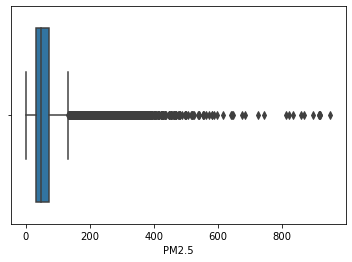

In [13]:
sns.boxplot(air["PM2.5"])
plt.show()

In [14]:
Q1=air["PM2.5"].quantile(0.25)  
Q3=air["PM2.5"].quantile(0.75)

In [15]:
Q1,Q3

(32.15, 72.45)

In [16]:
air.describe()

,PM2.5,PM10,NOx,NH3,CO,SO2,O3
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,64.510857,109.659366,31.063568,20.813789,2.153872,13.830897,33.994121
std,59.807551,72.324020,29.477748,21.028862,6.724660,17.005647,20.202304
min,0.040000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000
25%,32.150000,79.315000,14.670000,12.040000,0.540000,6.090000,20.740000
50%,48.570000,95.680000,23.520000,15.850000,0.890000,9.160000,30.840000
75%,72.450000,111.880000,36.015000,21.755000,1.380000,13.810000,42.730000
max,949.990000,1000.000000,467.630000,352.890000,175.810000,193.860000,257.730000


In [17]:
iqr=Q3-Q1
iqr

40.300000000000004

In [18]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr
upper_limit,lower_limit

(132.9, -28.300000000000004)

In [19]:
def limit_imputer(value):
    if value>upper_limit:
        return upper_limit
    elif value<lower_limit:
        return lower_limit
    else:
        return value
air["PM2.5"]=air["PM2.5"].apply(limit_imputer) 

In [20]:
air.describe()

,PM2.5,PM10,NOx,NH3,CO,SO2,O3
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,57.185400,109.659366,31.063568,20.813789,2.153872,13.830897,33.994121
std,34.928709,72.324020,29.477748,21.028862,6.724660,17.005647,20.202304
min,0.040000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000
25%,32.150000,79.315000,14.670000,12.040000,0.540000,6.090000,20.740000
50%,48.570000,95.680000,23.520000,15.850000,0.890000,9.160000,30.840000
75%,72.450000,111.880000,36.015000,21.755000,1.380000,13.810000,42.730000
max,132.900000,1000.000000,467.630000,352.890000,175.810000,193.860000,257.730000


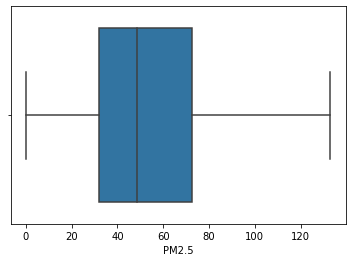

In [21]:
sns.boxplot(air["PM2.5"])
plt.show()

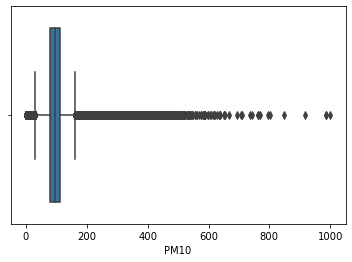

In [22]:
sns.boxplot(air["PM10"])
plt.show()

In [23]:
Q1=air["PM10"].quantile(0.25)  
Q3=air["PM10"].quantile(0.75)
Q1,Q3

(79.315, 111.88)

In [24]:
iqr=Q3-Q1
iqr

32.565

In [25]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr
upper_limit,lower_limit

(160.7275, 30.4675)

In [26]:
def limit_imputer(value):
    if value>upper_limit:
        return upper_limit
    elif value<lower_limit:
        return lower_limit
    else:
        return value
air["PM10"]=air["PM10"].apply(limit_imputer) 

In [27]:
air.describe()

,PM2.5,PM10,NOx,NH3,CO,SO2,O3
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,57.185400,97.465790,31.063568,20.813789,2.153872,13.830897,33.994121
std,34.928709,36.660354,29.477748,21.028862,6.724660,17.005647,20.202304
min,0.040000,30.467500,0.000000,0.010000,0.000000,0.010000,0.010000
25%,32.150000,79.315000,14.670000,12.040000,0.540000,6.090000,20.740000
50%,48.570000,95.680000,23.520000,15.850000,0.890000,9.160000,30.840000
75%,72.450000,111.880000,36.015000,21.755000,1.380000,13.810000,42.730000
max,132.900000,160.727500,467.630000,352.890000,175.810000,193.860000,257.730000


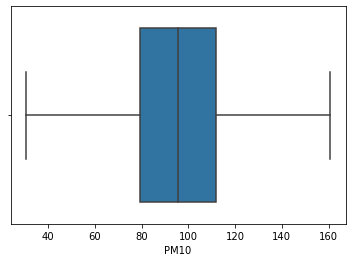

In [28]:
sns.boxplot(air["PM10"])
plt.show()

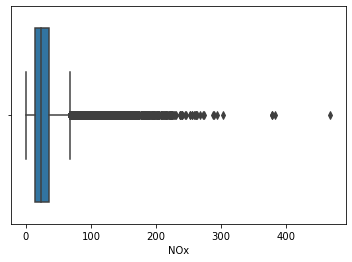

In [29]:
sns.boxplot(air["NOx"])
plt.show()

In [30]:
Q1=air["NOx"].quantile(0.25)  
Q3=air["NOx"].quantile(0.75)
Q1,Q3

(14.67, 36.015)

In [31]:
iqr=Q3-Q1
iqr

21.345

In [32]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr
upper_limit,lower_limit

(68.0325, -17.347499999999997)

In [33]:
def limit_imputer(value):
    if value>upper_limit:
        return upper_limit
    elif value<lower_limit:
        return lower_limit
    else:
        return value
air["NOx"]=air["NOx"].apply(limit_imputer) 

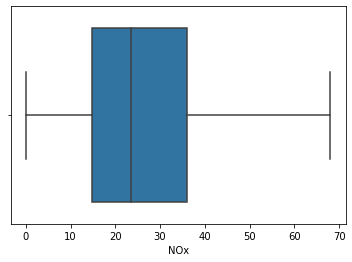

In [34]:
sns.boxplot(air["NOx"])
plt.show()

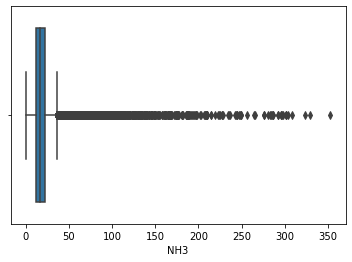

In [35]:
sns.boxplot(air["NH3"])
plt.show()

In [36]:
Q1=air["NH3"].quantile(0.25)  
Q3=air["NH3"].quantile(0.75)
Q1,Q3

(12.04, 21.755000000000003)

In [37]:
iqr=Q3-Q1
iqr

9.715000000000003

In [38]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr
upper_limit,lower_limit

(36.32750000000001, -2.532500000000006)

In [39]:
def limit_imputer(value):
    if value>upper_limit:
        return upper_limit
    elif value<lower_limit:
        return lower_limit
    else:
        return value
air["NH3"]=air["NH3"].apply(limit_imputer) 

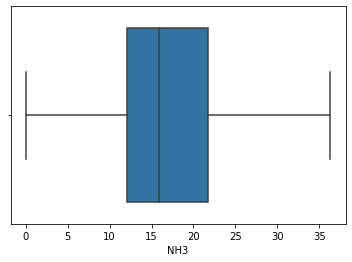

In [40]:
sns.boxplot(air["NH3"])
plt.show()

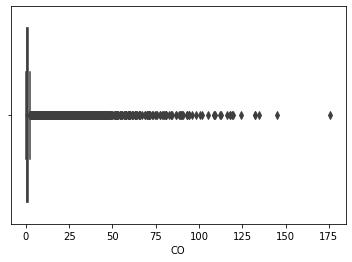

In [41]:
sns.boxplot(air["CO"])
plt.show()

In [42]:
Q1=air["CO"].quantile(0.25)  
Q3=air["CO"].quantile(0.75)
Q1,Q3

(0.54, 1.38)

In [43]:

iqr=Q3-Q1
iqr

0.8399999999999999

In [44]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr
upper_limit,lower_limit

(2.6399999999999997, -0.7199999999999998)

In [45]:
def limit_imputer(value):
    if value>upper_limit:
        return upper_limit
    elif value<lower_limit:
        return lower_limit
    else:
        return value
air["CO"]=air["CO"].apply(limit_imputer) 

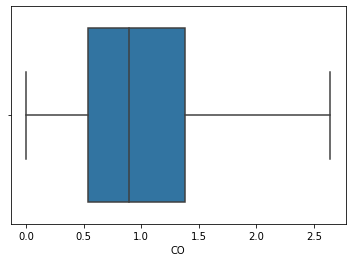

In [46]:

sns.boxplot(air["CO"])
plt.show()

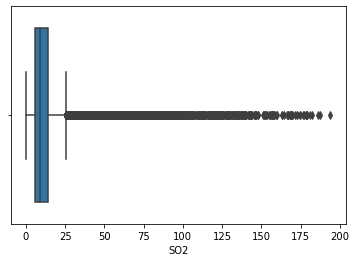

In [47]:

sns.boxplot(air["SO2"])
plt.show()

In [48]:
Q1=air["SO2"].quantile(0.25)  
Q3=air["SO2"].quantile(0.75)
Q1,Q3

(6.09, 13.81)

In [49]:
iqr=Q3-Q1
iqr


7.720000000000001

In [50]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr
upper_limit,lower_limit

(25.39, -5.490000000000002)

In [51]:
def limit_imputer(value):
    if value>upper_limit:
        return upper_limit
    elif value<lower_limit:
        return lower_limit
    else:
        return value
air["CO"]=air["CO"].apply(limit_imputer) 

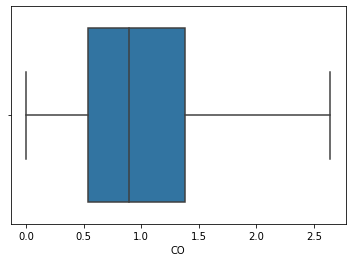

In [52]:
sns.boxplot(air["CO"])
plt.show()

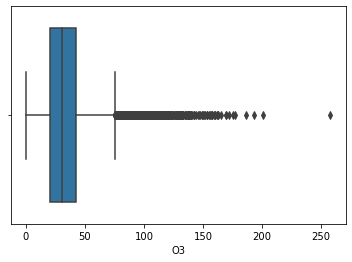

In [53]:
sns.boxplot(air["O3"])
plt.show()

In [54]:
Q1=air["O3"].quantile(0.25)  
Q3=air["O3"].quantile(0.75)
Q1,Q3


(20.74, 42.73)

In [55]:
iqr=Q3-Q1
iqr


21.99

In [56]:
upper_limit=Q3+1.5*iqr
lower_limit=Q1-1.5*iqr
upper_limit,lower_limit

(75.715, -12.245000000000001)

In [57]:
def limit_imputer(value):
    if value>upper_limit:
        return upper_limit
    elif value<lower_limit:
        return lower_limit
    else:
        return value
air["O3"]=air["O3"].apply(limit_imputer) 

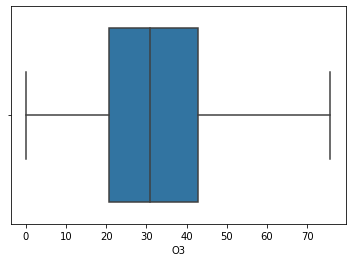

In [58]:
sns.boxplot(air["O3"])
plt.show()

In [59]:
air.describe()

,PM2.5,PM10,NOx,NH3,CO,SO2,O3
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,57.185400,97.465790,27.705994,17.720859,1.046907,13.830897,33.221570
std,34.928709,36.660354,18.903702,9.595420,0.745663,17.005647,17.699288
min,0.040000,30.467500,0.000000,0.010000,0.000000,0.010000,0.010000
25%,32.150000,79.315000,14.670000,12.040000,0.540000,6.090000,20.740000
50%,48.570000,95.680000,23.520000,15.850000,0.890000,9.160000,30.840000
75%,72.450000,111.880000,36.015000,21.755000,1.380000,13.810000,42.730000
max,132.900000,160.727500,68.032500,36.327500,2.640000,193.860000,75.715000


In [60]:
air.keys()

Index(['City', 'Date', 'PM2.5', 'PM10', 'NOx', 'NH3', 'CO', 'SO2', 'O3'], dtype='object')

In [61]:
air["PM10_24hr_avg"] = air.groupby("City")["PM10"].rolling(window = 24, min_periods = 16).mean().values
air["PM2.5_24hr_avg"] = air.groupby("City")["PM2.5"].rolling(window = 24, min_periods = 16).mean().values
air["SO2_24hr_avg"] = air.groupby("City")["SO2"].rolling(window = 24, min_periods = 16).mean().values
air["NOx_24hr_avg"] = air.groupby("City")["NOx"].rolling(window = 24, min_periods = 16).mean().values
air["NH3_24hr_avg"] = air.groupby("City")["NH3"].rolling(window = 24, min_periods = 16).mean().values
air["CO_8hr_max"] = air.groupby("City")["CO"].rolling(window = 8, min_periods = 1).max().values
air["O3_8hr_max"] = air.groupby("City")["O3"].rolling(window = 8, min_periods = 1).max().values

In [62]:
def get_PM25_subindex(x):
    if x <= 30:
        return x * 50 / 30
    elif x <= 60:
        return 50 + (x - 30) * 50 / 30
    elif x <= 90:
        return 100 + (x - 60) * 100 / 30
    elif x <= 120:
        return 200 + (x - 90) * 100 / 30
    elif x <= 250:
        return 300 + (x - 120) * 100 / 130
    elif x > 250:
        return 400 + (x - 250) * 100 / 130
    else:
        return 0
air["PM2.5_SubIndex"] = air["PM2.5_24hr_avg"].apply(lambda x: get_PM25_subindex(x))

In [63]:
def get_PM10_subindex(x):
    if x <= 50:
        return x
    elif x <= 100:
        return x
    elif x <= 250:
        return 100 + (x - 100) * 100 / 150
    elif x <= 350:
        return 200 + (x - 250)
    elif x <= 430:
        return 300 + (x - 350) * 100 / 80
    elif x > 430:
        return 400 + (x - 430) * 100 / 80
    else:
        return 0
air["PM10_SubIndex"] = air["PM10_24hr_avg"].apply(lambda x: get_PM10_subindex(x))

In [64]:
def get_SO2_subindex(x):
    if x <= 40:
        return x * 50 / 40
    elif x <= 80:
        return 50 + (x - 40) * 50 / 40
    elif x <= 380:
        return 100 + (x - 80) * 100 / 300
    elif x <= 800:
        return 200 + (x - 380) * 100 / 420
    elif x <= 1600:
        return 300 + (x - 800) * 100 / 800
    elif x > 1600:
        return 400 + (x - 1600) * 100 / 800
    else:
        return 0

air["SO2_SubIndex"] = air["SO2_24hr_avg"].apply(lambda x: get_SO2_subindex(x))

In [65]:
def get_NOx_subindex(x):
    if x <= 40:
        return x * 50 / 40
    elif x <= 80:
        return 50 + (x - 40) * 50 / 40
    elif x <= 180:
        return 100 + (x - 80) * 100 / 100
    elif x <= 280:
        return 200 + (x - 180) * 100 / 100
    elif x <= 400:
        return 300 + (x - 280) * 100 / 120
    elif x > 400:
        return 400 + (x - 400) * 100 / 120
    else:
        return 0

air["NOx_SubIndex"] = air["NOx_24hr_avg"].apply(lambda x: get_NOx_subindex(x))

In [66]:
def get_NH3_subindex(x):
    if x <= 200:
        return x * 50 / 200
    elif x <= 400:
        return 50 + (x - 200) * 50 / 200
    elif x <= 800:
        return 100 + (x - 400) * 100 / 400
    elif x <= 1200:
        return 200 + (x - 800) * 100 / 400
    elif x <= 1800:
        return 300 + (x - 1200) * 100 / 600
    elif x > 1800:
        return 400 + (x - 1800) * 100 / 600
    else:
        return 0
air["NH3_SubIndex"] = air["NH3_24hr_avg"].apply(lambda x: get_NH3_subindex(x))


In [67]:
def get_CO_subindex(x):
    if x <= 1:
        return x * 50 / 1
    elif x <= 2:
        return 50 + (x - 1) * 50 / 1
    elif x <= 10:
        return 100 + (x - 2) * 100 / 8
    elif x <= 17:
        return 200 + (x - 10) * 100 / 7
    elif x <= 34:
        return 300 + (x - 17) * 100 / 17
    elif x > 34:
        return 400 + (x - 34) * 100 / 17
    else:
        return 0

air["CO_SubIndex"] = air["CO_8hr_max"].apply(lambda x: get_CO_subindex(x))

In [68]:
#ozone
def get_O3_subindex(x):
    if x <= 50:
        return x * 50 / 50
    elif x <= 100:
        return 50 + (x - 50) * 50 / 50
    elif x <= 168:
        return 100 + (x - 100) * 100 / 68
    elif x <= 208:
        return 200 + (x - 168) * 100 / 40
    elif x <= 748:
        return 300 + (x - 208) * 100 / 539
    elif x > 748:
        return 400 + (x - 400) * 100 / 539
    else:
        return 0
air["O3_SubIndex"] = air["O3_8hr_max"].apply(lambda x: get_O3_subindex(x))

In [69]:
## AQI bucketing
def get_AQI_bucket(x):
    if x <= 50:
        return "Good"
    elif x <= 100:
        return "Satisfactory"
    elif x <= 200:
        return "Moderate"
    elif x <= 300:
        return "Poor"
    elif x <= 400:
        return "Very Poor"
    elif x > 400:
        return "Severe"
    else:
        return np.NaN

air["Checks"] = (air["PM2.5_SubIndex"] > 0).astype(int) + \
                (air["PM10_SubIndex"] > 0).astype(int) + \
                (air["SO2_SubIndex"] > 0).astype(int) + \
                (air["NOx_SubIndex"] > 0).astype(int) + \
                (air["NH3_SubIndex"] > 0).astype(int) + \
                (air["CO_SubIndex"] > 0).astype(int) + \
                (air["O3_SubIndex"] > 0).astype(int)

air["AQI_calculated"] = round(air[["PM2.5_SubIndex", "PM10_SubIndex", "SO2_SubIndex", "NOx_SubIndex",
                                 "NH3_SubIndex", "CO_SubIndex", "O3_SubIndex"]].max(axis = 1))
air["AQI_bucket_calculated"] = air["AQI_calculated"].apply(lambda x: get_AQI_bucket(x))

In [70]:
air["AQI_bucket_calculated"].value_counts()

Satisfactory    12109
Moderate        11250
Poor             2709
Very Poor        1982
Good             1481
Name: AQI_bucket_calculated, dtype: int64

In [71]:
air.head()

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,PM10_24hr_avg,...,PM2.5_SubIndex,PM10_SubIndex,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex,Checks,AQI_calculated,AQI_bucket_calculated
0,Ahmedabad,1/1/2015,48.57,95.68,17.15,15.85,0.92,27.64,75.715,NaN,...,0.0,0.0,0.0,0.0,0.0,46.0,75.715,2,76.0,Satisfactory
1,Ahmedabad,1/2/2015,48.57,95.68,16.46,15.85,0.97,24.55,34.060,NaN,...,0.0,0.0,0.0,0.0,0.0,48.5,75.715,2,76.0,Satisfactory
2,Ahmedabad,1/3/2015,48.57,95.68,29.70,15.85,2.64,29.07,30.700,NaN,...,0.0,0.0,0.0,0.0,0.0,108.0,75.715,2,108.0,Moderate
3,Ahmedabad,1/4/2015,48.57,95.68,17.97,15.85,1.70,18.59,36.080,NaN,...,0.0,0.0,0.0,0.0,0.0,108.0,75.715,2,108.0,Moderate
4,Ahmedabad,1/5/2015,48.57,95.68,37.76,15.85,2.64,39.33,39.310,NaN,...,0.0,0.0,0.0,0.0,0.0,108.0,75.715,2,108.0,Moderate


In [72]:
air["City"].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [73]:
air['Acceptable AQI_bucket'] = np.where((air['AQI_bucket_calculated']=='Poor') | (air['AQI_bucket_calculated']=='Moderate') | (air['AQI_bucket_calculated']=='Very Poor') ,0,1)


In [74]:
air['Acceptable AQI_bucket'].value_counts()

0    15941
1    13590
Name: Acceptable AQI_bucket, dtype: int64

In [75]:
air["City"].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [76]:
mapping={'Ahmedabad': 0,
        'Aizawl': 1,
          'Amaravati': 2,
         'Amritsar': 3,
         'Bengaluru': 4,
         'Bhopal': 5,
       'Brajrajnagar': 6,
         'Chandigarh': 7,
         'Chennai': 8,
         'Coimbatore': 9,
       'Delhi': 10,
         'Ernakulam': 11,
         'Gurugram': 12,
         'Guwahati': 13,
       'Hyderabad': 14,
         'Jaipur': 15,
         'Jorapokhar': 16,
         'Kochi': 17,
         'Kolkata': 18,
       'Lucknow': 19,
         'Mumbai': 20,
         'Patna': 21,
         'Shillong': 22,
         'Talcher': 23,
       'Thiruvananthapuram': 24,
         'Visakhapatnam': 25}


In [77]:
air["States Index"]=air["City"].map(mapping)

In [78]:
air["States Index"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25], dtype=int64)

In [79]:
air.head()

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,PM10_24hr_avg,...,SO2_SubIndex,NOx_SubIndex,NH3_SubIndex,CO_SubIndex,O3_SubIndex,Checks,AQI_calculated,AQI_bucket_calculated,Acceptable AQI_bucket,States Index
0,Ahmedabad,1/1/2015,48.57,95.68,17.15,15.85,0.92,27.64,75.715,NaN,...,0.0,0.0,0.0,46.0,75.715,2,76.0,Satisfactory,1,0
1,Ahmedabad,1/2/2015,48.57,95.68,16.46,15.85,0.97,24.55,34.060,NaN,...,0.0,0.0,0.0,48.5,75.715,2,76.0,Satisfactory,1,0
2,Ahmedabad,1/3/2015,48.57,95.68,29.70,15.85,2.64,29.07,30.700,NaN,...,0.0,0.0,0.0,108.0,75.715,2,108.0,Moderate,0,0
3,Ahmedabad,1/4/2015,48.57,95.68,17.97,15.85,1.70,18.59,36.080,NaN,...,0.0,0.0,0.0,108.0,75.715,2,108.0,Moderate,0,0
4,Ahmedabad,1/5/2015,48.57,95.68,37.76,15.85,2.64,39.33,39.310,NaN,...,0.0,0.0,0.0,108.0,75.715,2,108.0,Moderate,0,0


In [96]:
import matplotlib.pyplot as plt

In [97]:
%matplotlib inline

In [98]:
from matplotlib import style

In [121]:
SO2 = air['SO2'].tolist()

In [135]:
stateindex=air['States Index'].tolist()


In [125]:
k = []
k=air['States Index'].value_counts()
k

0     2009
10    2009
19    2009
4     2009
20    2009
8     2009
14    2006
21    1858
12    1679
25    1462
3     1221
16    1169
15    1114
24    1112
2      951
6      938
23     925
18     814
13     502
9      386
22     310
7      304
5      289
11     162
17     162
1      113
Name: States Index, dtype: int64

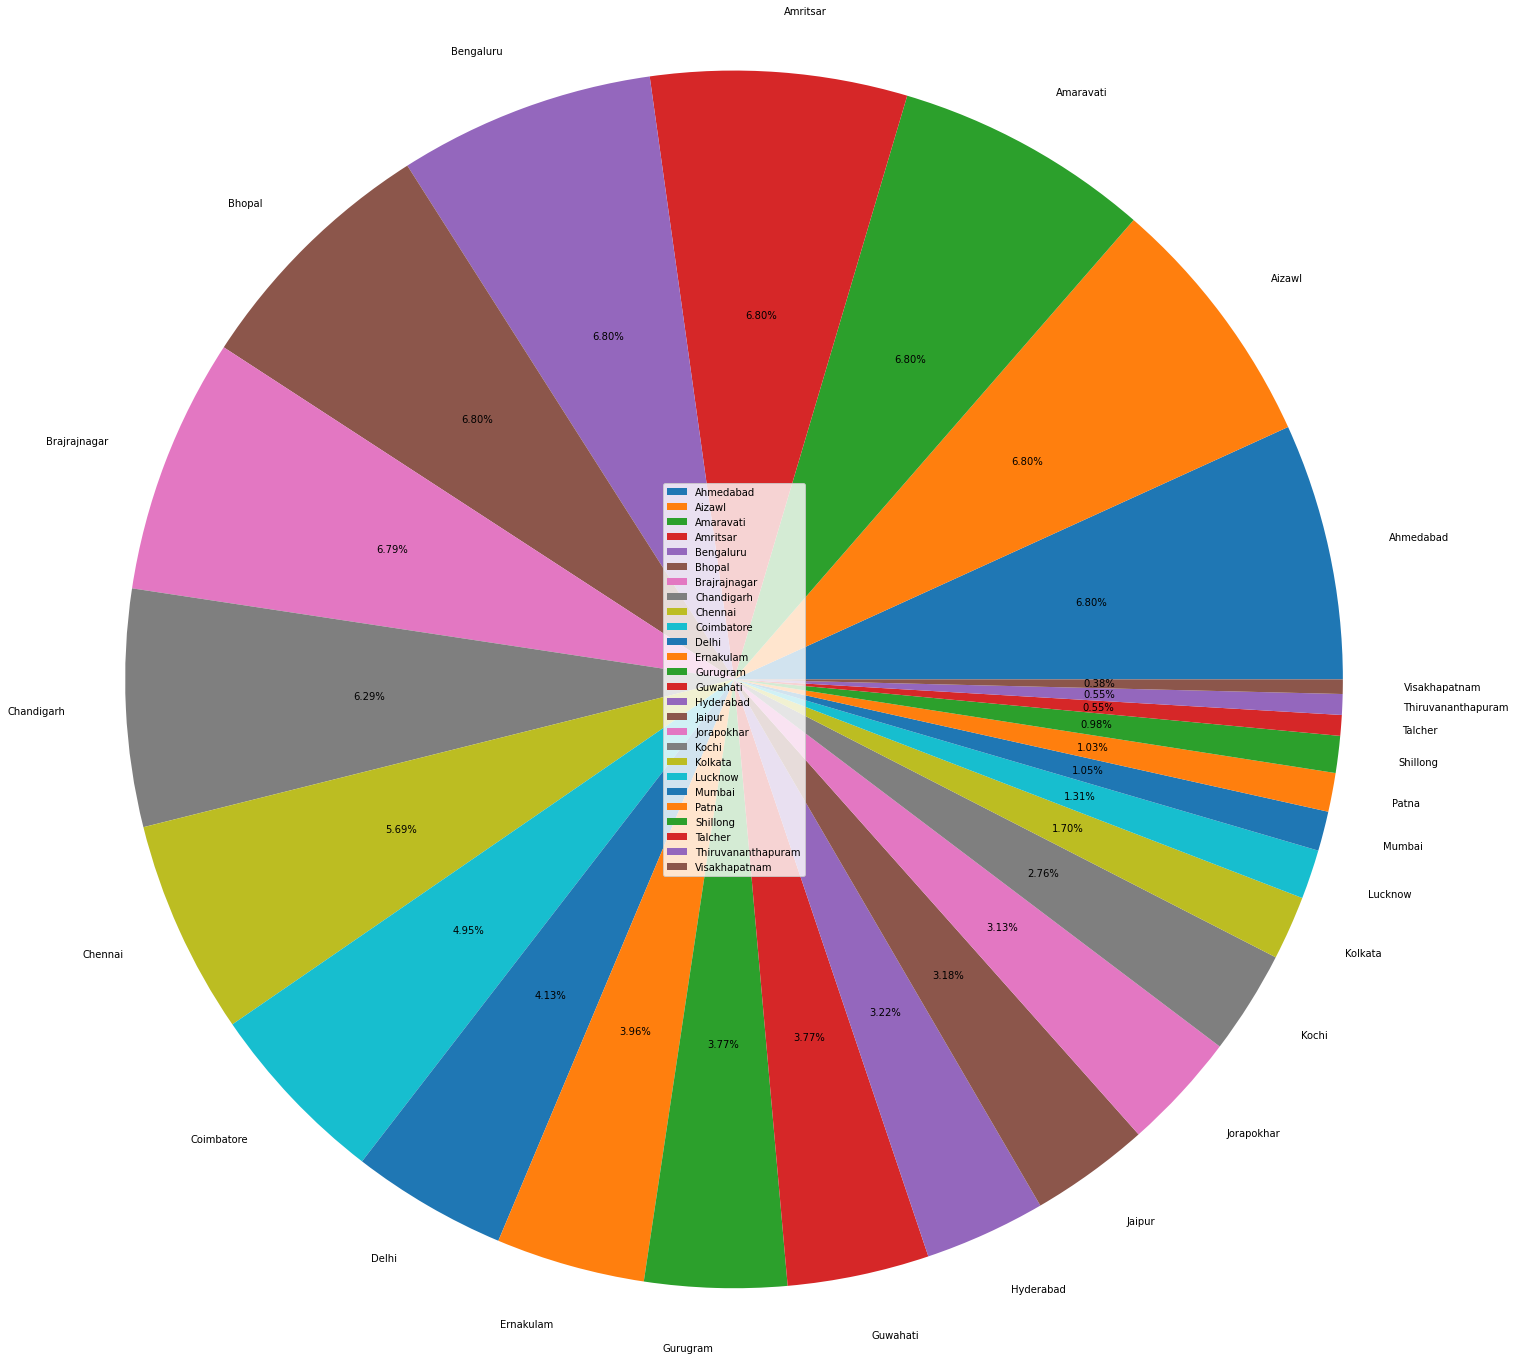

In [141]:
plt.pie(k, labels=['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], radius=7,autopct="%1.2f%%")
plt.legend(loc=10)
plt.show()

# Train and Test Split

In [80]:
x=air.iloc[:,[27]]

In [81]:
x.head()

,States Index
0,0
1,0
2,0
3,0
4,0


In [82]:
y=air.iloc[:,[26]]

In [83]:
y.head()

,Acceptable AQI_bucket
0,1
1,1
2,0
3,0
4,0


In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.3,random_state=101)

In [86]:
print(Y_train.value_counts(normalize=True).round(2))
print(Y_test.value_counts(normalize=True).round(2))

Acceptable AQI_bucket
0                        0.54
1                        0.46
dtype: float64
Acceptable AQI_bucket
0                        0.54
1                        0.46
dtype: float64


# LOGISTICAL REGRESSION

In [87]:
from sklearn.linear_model import LogisticRegression

In [88]:
logmodel=LogisticRegression()

In [89]:
logmodel.fit(X_train,Y_train)

LogisticRegression()

In [90]:
predictions=logmodel.predict(X_test)

In [91]:
from sklearn.metrics import confusion_matrix, classification_report

In [92]:
confu=confusion_matrix(Y_test,predictions)

In [93]:
confu

array([[4795,    0],
       [4065,    0]], dtype=int64)

In [94]:
from sklearn.metrics import accuracy_score

In [95]:
accuracy_score(Y_test,predictions)

0.541196388261851

In [104]:
from sklearn.metrics import confusion_matrix  
cm= confusion_matrix(Y_test, predictions) 

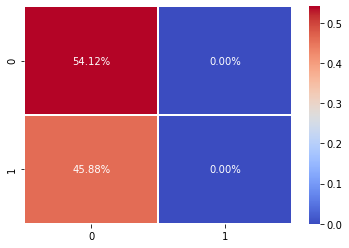

In [105]:
s= sns.heatmap(cm/np.sum(cm),linewidth=0.8,annot=True,fmt=".2%", cmap="coolwarm")
plt.show()

# Random Forest Classifier

In [106]:
from sklearn.ensemble import RandomForestClassifier

In [107]:
classifier = RandomForestClassifier(n_estimators=100, criterion='gini')
classifier.fit(X_train, Y_train)

RandomForestClassifier()

In [108]:
pr=classifier.predict(X_test)

In [109]:
classifier.score(Y_test,pr)

0.7152370203160271

In [110]:
from sklearn.metrics import confusion_matrix  
c= confusion_matrix(Y_test, pr) 

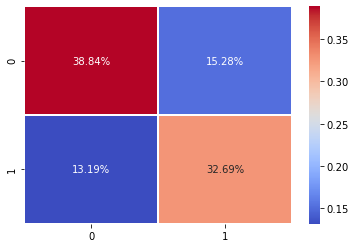

In [111]:
s= sns.heatmap(c/np.sum(cm),linewidth=0.8,annot=True,fmt=".2%", cmap="coolwarm")
plt.show()

# KNN Algorithm

In [112]:
from sklearn.neighbors import KNeighborsClassifier  
classifier= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2 )  
classifier.fit(X_train, Y_train)  

KNeighborsClassifier()

In [113]:
y_pred= classifier.predict(X_test)  

In [114]:
from sklearn.metrics import confusion_matrix  
m= confusion_matrix(Y_test, y_pred)

In [115]:
m

array([[3445, 1350],
       [1738, 2327]], dtype=int64)

In [116]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.72      0.69      4795
           1       0.63      0.57      0.60      4065

    accuracy                           0.65      8860
   macro avg       0.65      0.65      0.65      8860
weighted avg       0.65      0.65      0.65      8860



In [117]:
from sklearn.metrics import accuracy_score

In [118]:
accuracy_score(Y_test,y_pred)

0.6514672686230248

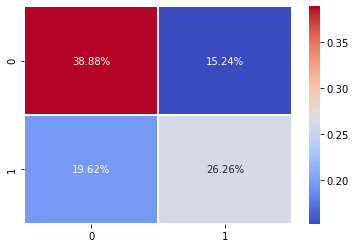

In [119]:
s= sns.heatmap(m/np.sum(cm),linewidth=0.8,annot=True,fmt=".2%", cmap="coolwarm")
plt.show()